## Step 1: Load Dataset

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "Tobi-Bueck/customer-support-tickets"
)

df = dataset["train"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

## Step 2: Explore Dataset

In [2]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [3]:
print("Shape:", df.shape)


Shape: (61765, 16)


In [4]:
print("\nColumns:")
print(df.columns.tolist())



Columns:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
subject      5299
body            2
answer      13189
type        13178
queue           0
priority        0
language        0
version     33178
tag_1       13178
tag_2       13237
tag_3       13409
tag_4       17775
tag_5       34129
tag_6       48540
tag_7       55797
tag_8       59293
dtype: int64


In [6]:
# Handle missing values

df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

# Verify

print(df[["subject", "body"]].isnull().sum())

subject    0
body       0
dtype: int64


In [7]:
print("\nDuplicates:")
print(df.duplicated().sum())


Duplicates:
0


In [8]:
df["language"].value_counts()


language
de    33504
en    28261
Name: count, dtype: int64

# Use english records only

In [9]:
df = df[df["language"] == "en"].copy()

In [10]:

df["queue"].value_counts()


queue
Technical Support                  8149
Product Support                    5305
Customer Service                   4269
IT Support                         3333
Billing and Payments               2897
Returns and Exchanges              1402
Service Outages and Maintenance    1106
Sales and Pre-Sales                 843
Human Resources                     553
General Inquiry                     404
Name: count, dtype: int64

In [11]:

df["priority"].value_counts()

priority
medium    11570
high      10917
low        5774
Name: count, dtype: int64

In [12]:
df.shape

(28261, 16)

# Build ML Pipeline

## Step 1: Create Feature Text

In [13]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

df["text"] = df["subject"] + " " + df["body"]

In [14]:
df["text"].head()

1    Account Disruption Dear Customer Support Team,...
2    Query About Smart Home System Integration Feat...
3    Inquiry Regarding Invoice Details Dear Custome...
4    Question About Marketing Agency Software Compa...
5    Feature Query Dear Customer Support,\n\nI hope...
Name: text, dtype: object

## Step 2: Clean Text

In [15]:
import re

def clean_text(text):
    
    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [16]:
df["clean_text"] = df["text"].apply(clean_text)

In [17]:
df[["text", "clean_text"]].head()

,text,clean_text
1,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support team ...
2,Query About Smart Home System Integration Feat...,query about smart home system integration feat...
3,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...
4,Question About Marketing Agency Software Compa...,question about marketing agency software compa...
5,"Feature Query Dear Customer Support,\n\nI hope...",feature query dear customer support n ni hope ...


## Step 3: Define Features & Target

# For queue classification

In [18]:
X = df["clean_text"]

y_queue = df["queue"]

## Step 4: Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train_queue, X_test_queue, y_train_queue, y_test_queue = train_test_split(
    X,
    y_queue,
    test_size=0.2,
    random_state=42,
    stratify=y_queue
)

print("Train Shape:", X_train_queue.shape)
print("Test Shape:", X_test_queue.shape)

Train Shape: (22608,)
Test Shape: (5653,)


## Step 5: Build Queue Classification Model

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [21]:
queue_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1,2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        )
    )
])

## Step 6: Train Queue Model

In [22]:
queue_model.fit(
    X_train_queue,
    y_train_queue
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

## Step 7: Predict

In [23]:
queue_pred = queue_model.predict(
    X_test_queue
)

## Step 8: Evaluate Queue Model

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [25]:
print(
    "Queue Accuracy:",
    accuracy_score(
        y_test_queue,
        queue_pred
    )
)

Queue Accuracy: 0.5566955598797099


In [26]:
print(
    classification_report(
        y_test_queue,
        queue_pred
    )
)

                                 precision    recall  f1-score   support

           Billing and Payments       0.81      0.79      0.80       579
               Customer Service       0.51      0.48      0.49       854
                General Inquiry       0.43      0.68      0.53        81
                Human Resources       0.54      0.77      0.63       111
                     IT Support       0.45      0.56      0.50       667
                Product Support       0.57      0.46      0.51      1061
          Returns and Exchanges       0.47      0.68      0.55       280
            Sales and Pre-Sales       0.35      0.68      0.46       169
Service Outages and Maintenance       0.55      0.77      0.64       221
              Technical Support       0.64      0.49      0.56      1630

                       accuracy                           0.56      5653
                      macro avg       0.53      0.64      0.57      5653
                   weighted avg       0.58      0

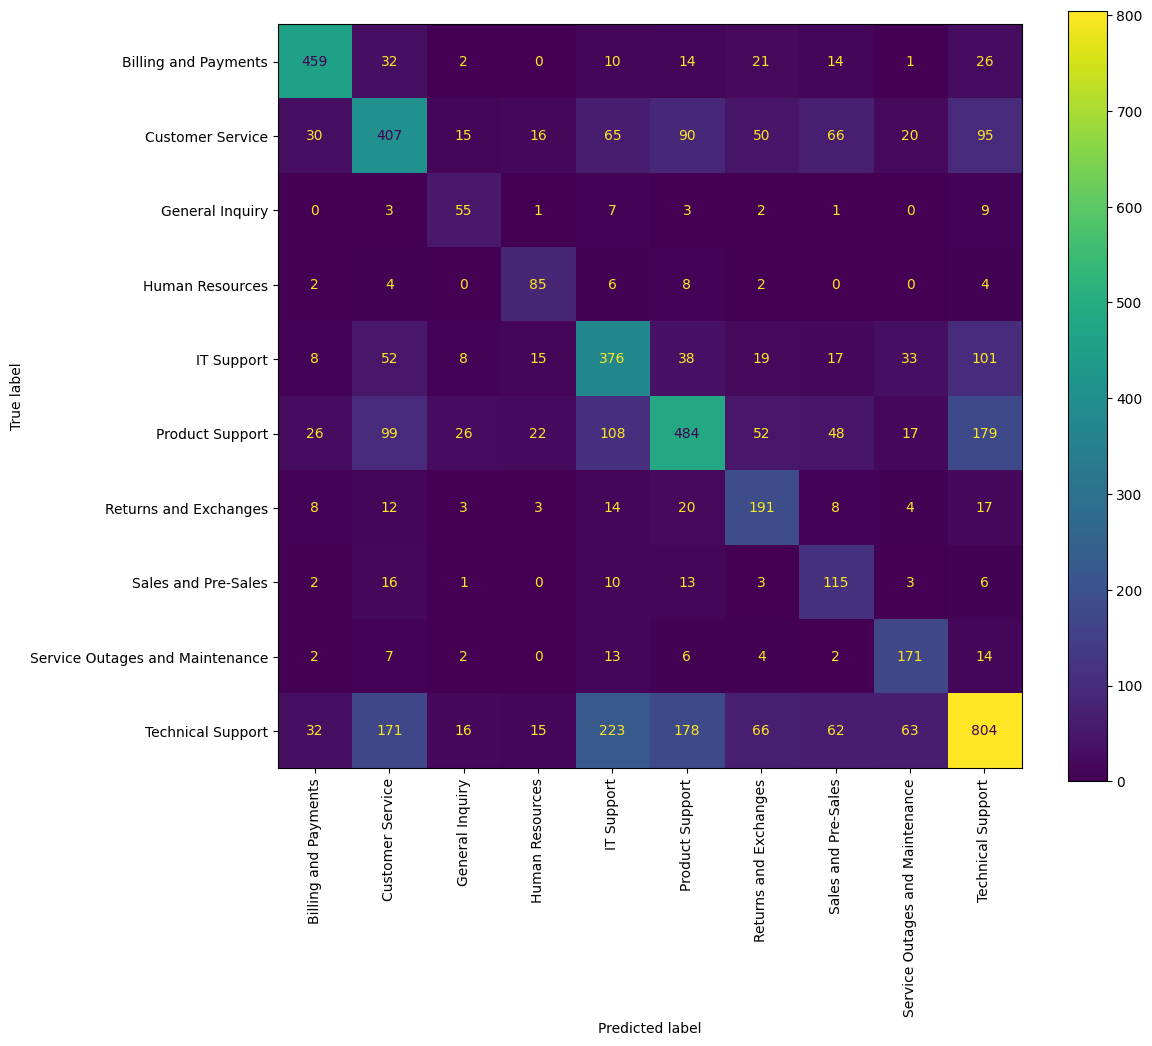

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test_queue,
    queue_pred,
    xticks_rotation=90,
    ax=ax
)

plt.show()

## Train Priority Model

In [28]:
y_priority = df["priority"]

In [29]:
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

# Create Priority Model

In [30]:
priority_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1,2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        )
    )
])

## Train

In [31]:
priority_model.fit(
    X_train_pri,
    y_train_pri
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

## predict

In [32]:
priority_pred = priority_model.predict(
    X_test_pri
)

   ## Evaluate

In [33]:
from sklearn.metrics import accuracy_score

print(
    "Priority Accuracy:",
    accuracy_score(
        y_test_pri,
        priority_pred
    )
)

Priority Accuracy: 0.6661949407394304


In [34]:
print(
    classification_report(
        y_test_pri,
        priority_pred
    )
)

              precision    recall  f1-score   support

        high       0.71      0.69      0.70      2184
         low       0.56      0.66      0.61      1155
      medium       0.69      0.65      0.67      2314

    accuracy                           0.67      5653
   macro avg       0.65      0.67      0.66      5653
weighted avg       0.67      0.67      0.67      5653



## Save Models

In [35]:
import joblib

joblib.dump(
    queue_model,
    "queue_model.pkl"
)

joblib.dump(
    priority_model,
    "priority_model.pkl"
)

['priority_model.pkl']

In [36]:
sample = """
My payment was deducted twice and the order was not placed.
Please refund immediately.
"""

In [37]:
queue_model.predict([sample])

array(['Billing and Payments'], dtype=object)

In [38]:
priority_model.predict([sample])

array(['high'], dtype=object)

In [39]:
accuracy_score(y_test_pri, priority_pred)

0.6661949407394304

## Create Routing logic

In [40]:
TEAM_MAPPING = {
    "Technical Support": "Tech Team",
    "IT Support": "IT Team",
    "Billing and Payments": "Finance Team",
    "Customer Service": "Customer Success Team",
    "Returns and Exchanges": "Operations Team",
    "Product Support": "Product Team"
}

## Create SLA Logic

In [41]:
SLA_MAPPING = {
    "high": "4 Hours",
    "medium": "24 Hours",
    "low": "72 Hours"
}

## Create Prediction Fucntion

In [42]:
def route_ticket(ticket_text):

    queue = queue_model.predict([ticket_text])[0]

    priority = priority_model.predict([ticket_text])[0]

    team = TEAM_MAPPING.get(queue, "Default Team")

    sla = SLA_MAPPING.get(priority, "24 Hours")

    return {
        "queue": queue,
        "priority": priority,
        "team": team,
        "sla": sla
    }

In [43]:
ticket = """
My payment was deducted twice but order was not placed.
Need refund urgently.
"""

route_ticket(ticket)

{'queue': 'Billing and Payments',
 'priority': 'high',
 'team': 'Finance Team',
 'sla': '4 Hours'}